In [169]:
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc,
    precision_recall_curve, average_precision_score, precision_score, recall_score, f1_score, log_loss
)

In [170]:
os.makedirs("out/plots", exist_ok=True)

In [171]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text)

    text = re.sub(r'<.*?>', ' ', text) #remove html tags
    text = re.sub(r'http\S+', ' ', text) #remove urls
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) #remove puctutation marks and numbers
    text = text.lower() #convert text into lowercase

    tokens = [w for w in text.split() if w not in stop_words and len(w) > 2] #remove stop words and words with length less than 3
    tokens = [lemmatizer.lemmatize(w) for w in tokens] #lemmatize the words

    return ' '.join(tokens)

In [172]:
#Helper function to load training data
def load_training_data(path):
    texts, labels = [], []

    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 4:
                label = int(parts[0]) #label
                title = parts[1] #title
                body = parts[3] #body

                texts.append(title + " " + body)
                labels.append(label)

    return texts, labels

In [173]:
#Helper function to load test data
def load_test_data(path):
    texts = []

    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                title = parts[0] #title
                body = parts[2] #body

                texts.append(title + " " + body)

    return texts

In [174]:
#Cleaning data
X_raw, y = load_training_data("data/trainset.txt")
X_test_raw = load_test_data("data/testsetwithoutlabels.txt")

X_clean = [clean_text(x) for x in X_raw]
X_test_clean = [clean_text(x) for x in X_test_raw]

In [175]:
#Splitting data into training and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)

In [176]:
#Tf idf vectorization
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test_clean)

In [177]:
#Grid search for hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=2000),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_vec, y_train)

best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'C': 10, 'solver': 'liblinear'}
Best CV Score: 0.98125


In [178]:
cv_results = pd.DataFrame(grid.cv_results_)
cv_table = cv_results[['param_C','param_solver','mean_test_score','rank_test_score']]
cv_table.to_csv("out/cv/results.csv", index=False)

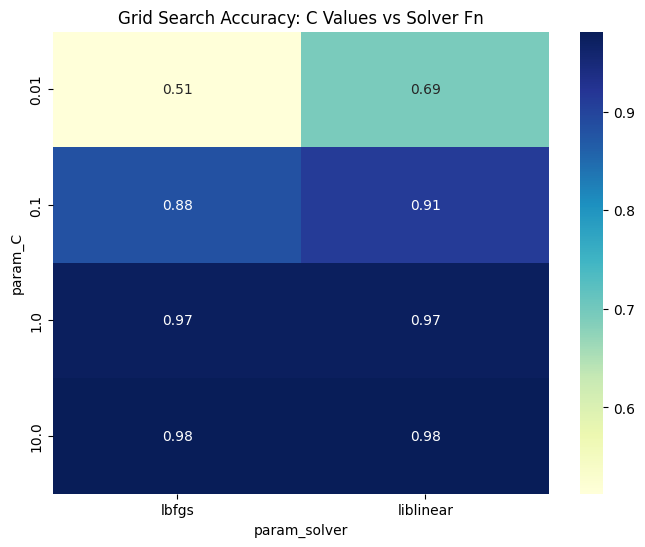

<Figure size 640x480 with 0 Axes>

In [179]:
# Reshape data for a heatmap
pivot_table = cv_table.pivot(index='param_C', columns='param_solver', values='mean_test_score')

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu')
plt.title('Grid Search Accuracy: C Values vs Solver Fn')
plt.show()
plt.savefig("out/plots/grid_search_heatmap.png")

In [180]:
y_pred = best_model.predict(X_val_vec)

print("\nAccuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))


Accuracy: 0.975
              precision    recall  f1-score   support

          -1       0.95      1.00      0.98        20
           1       1.00      0.95      0.97        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



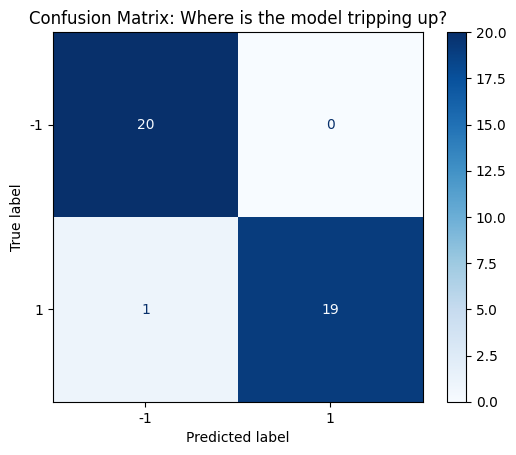

<Figure size 640x480 with 0 Axes>

In [181]:
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Where is the model tripping up?")
plt.show()
plt.savefig("out/plots/confusion_matrix.png")

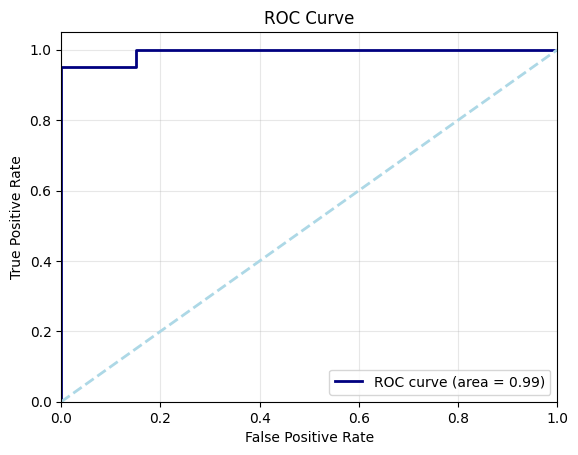

In [182]:
y_probs = best_model.predict_proba(X_val_vec)[:, 1]

#Calculate the FPR, TPR and Area Under Curve (AUC)
fpr, tpr, _ = roc_curve(y_val, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='navy', lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='lightblue', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig("out/plots/roc_curve.png")
plt.show()


In [183]:
precision = precision_score(y_val, y_pred, average='weighted')
recall = recall_score(y_val, y_pred, average='weighted')
f1 = f1_score(y_val, y_pred, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Precision: 0.9762
Recall:    0.9750
F1-Score:  0.9750


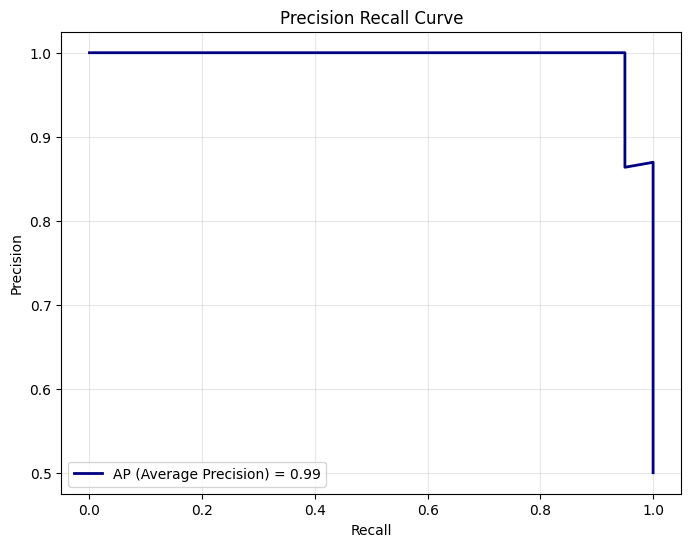

In [184]:
# Precision, Recall, and Average Precision
precision, recall, _ = precision_recall_curve(y_val, y_probs)
ap = average_precision_score(y_val, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='navy', lw=2, label=f"AP (Average Precision) = {ap:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.savefig("out/plots/pr_curve.png") 
plt.show()

In [185]:
loss_val = log_loss(y_val, y_probs)
print(f"Log Loss Score: {loss_val:.4f}")

Log Loss Score: 0.2251


In [186]:
feature_names = vectorizer.get_feature_names_out()
coef = best_model.coef_[0]

top_pos = np.argsort(coef)[-15:]
top_neg = np.argsort(coef)[:15]

print("\nTop Positive Words:")
for i in reversed(top_pos):
    print(feature_names[i], coef[i])

print("\nTop Negative Words:")
for i in top_neg:
    print(feature_names[i], coef[i])


Top Positive Words:
wheat 2.697285580816274
coffee 2.6696498705604443
tonne 2.60935872279534
sugar 2.6014879560614226
grain 2.467844441273135
soybean 2.0610974449659487
export 1.7612909644633055
corn 1.7073730996055398
nil 1.6486637120664362
lyng 1.548540337872032
brazil 1.3855521527996202
agriculture 1.384070939977152
maize 1.2875483259265483
crop 1.2816645870265986
usda 1.2364738643480093

Top Negative Words:
gold -3.788020168983162
copper -3.2771023028524997
steel -2.741467650393239
zinc -2.3406396580938815
mine -2.306712077200359
silver -2.091366621136233
ounce -2.0025921706782435
ton -1.85327336683335
ore -1.8212853144369496
mining -1.6659126508168758
company -1.6422062830916397
ltd -1.5325707253779868
metal -1.448846075401329
lb -1.448207651517972
inc -1.3481810326307662


C:\Users\isula\AppData\Local\Temp\ipykernel_21152\1933204438.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coefficient', y='word', data=features, palette=colors)


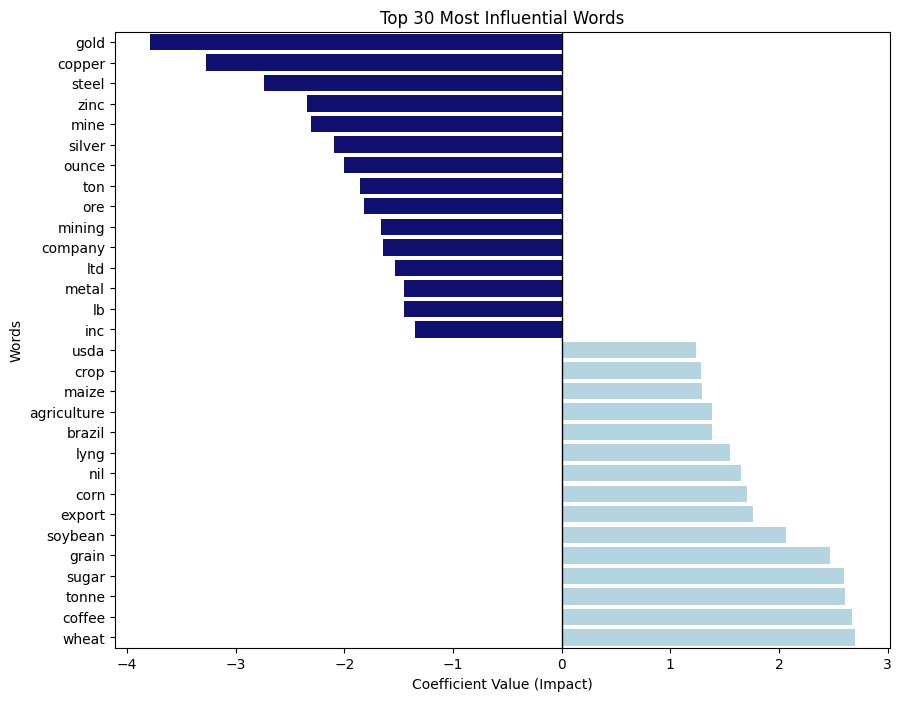

In [187]:
features = pd.DataFrame({
    'word': np.concatenate([feature_names[top_neg], feature_names[top_pos]]),
    'coefficient': np.concatenate([coef[top_neg], coef[top_pos]])
})


features = features.sort_values(by='coefficient')
plt.figure(figsize=(10, 8))
colors = ['navy' if x < 0 else 'lightblue' for x in features['coefficient']]
sns.barplot(x='coefficient', y='word', data=features, palette=colors)
plt.title("Top 30 Most Influential Words")
plt.xlabel("Coefficient Value (Impact)")
plt.ylabel("Words")
plt.axvline(0, color='black', lw=1)
plt.savefig("out/plots/feature_importance.png")
plt.show()

In [188]:
with open("data/testsetwithoutlabels.txt", "r", encoding="utf-8") as f:
    lines = f.readlines()

titles = []
bodies = []

for line in lines:
    parts = line.split('\t')
    if len(parts) >= 3:
        titles.append(parts[0])
        bodies.append(parts[2])
    else:
        titles.append("No Title")
        bodies.append(line)

test_predictions = best_model.predict(X_test_vec)

output_df = pd.DataFrame({
    'title': titles,
    'body': bodies,
    'prediction': test_predictions
})

output_df.to_csv("out/pred/final_results_fixed.csv", index=False)

In [189]:
prediction_counts = output_df['prediction'].value_counts()

# .get() to avoid errors if a class has 0 predictions
num_pos = prediction_counts.get(1, 0)
num_neg = prediction_counts.get(-1, 0)


print("PREDICTION SUMMARY")
print()
print(f"Total Positive (1):  {num_pos}")
print(f"Total Negative (-1): {num_neg}")
print()
print(f"Total Samples:       {len(output_df)}")
pos_percent = (num_pos / len(output_df)) * 100
print()
print(f"Positive Rate: {pos_percent:.2f}%")

PREDICTION SUMMARY

Total Positive (1):  49
Total Negative (-1): 51

Total Samples:       100

Positive Rate: 49.00%
